In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import scanpy as sc
from src.scmrdr.module import Integration

print("正在加载数据...")
adata = sc.read_h5ad("./experiments/BMMC_codes/feature_aligned_sampled.h5ad")
print(f"原始数据形状: {adata.shape}")

# === 新增步骤：筛选高变特征 ===
# 建议将特征数控制在 2000 左右，否则显存会爆
target_features = 2000 

if adata.shape[1] > target_features:
    print(f"特征数量过多 ({adata.shape[1]})，正在筛选前 {target_features} 个高变特征...")
    
    # 注意：如果是多模态数据，最好分别对 RNA 和 ATAC 筛选，或者如果数据已经预处理过，
    # 直接随机采样或取方差最大的前 2000 个
    # 这里使用简单的方差筛选作为示例：
    sc.pp.highly_variable_genes(adata, n_top_genes=target_features, subset=True)
    
    print(f"筛选后数据形状: {adata.shape}")
# ============================

# 2. 初始化模型
# 注意：你的数据里 layer 名字叫 'counts' (多了个s)，原代码是 'count'，这里要改一下
model = Integration(
    data=adata, 
    modality_key="modality", 
    layer="counts",       # <--- 重点：改成 counts
    batch_key="batch",    # 你的数据里有 batch 列，直接用
    feature_list=None,    # 你已经对齐了特征，这里填 None 即可
    distribution="ZINB"
)

# 3. 设置参数
model.setup(hidden_layers=[512,512], latent_dim_shared=20, latent_dim_specific=20, gamma=1000, lambda_adv=10, dropout_rate=0.2)

# 4. 开始训练
print("开始训练模型...")
model.train(epoch_num=300, batch_size=128, lr=1e-3, adaptlr=False, num_warmup=0,
            early_stopping=False, valid_prop=0.1, weighted=False, patience=10)

# 5. 推断与获取结果
print("正在推断潜在空间...")
model.inference(n_samples=1, update=True, returns=False)
adata = model.get_adata() # 结果存储在 adata.obsm["latent_shared"]

# 6. 可视化
print("正在绘图...")
sc.pp.neighbors(adata, use_rep="latent_shared")
sc.tl.umap(adata)
sc.pl.umap(
    adata,
    color=["modality", "celltype", "batch"], # 注意：你的数据里叫 celltype
    size=2, wspace=0.5
)

正在加载数据...


/root/miniconda3/envs/scMRDR/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


原始数据形状: (58868, 10170)
特征数量过多 (10170)，正在筛选前 2000 个高变特征...


/root/miniconda3/envs/scMRDR/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/root/miniconda3/envs/scMRDR/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


筛选后数据形状: (58868, 2000)
using cuda
开始训练模型...
Training start!
epoch 1: loss = 1497.7500, Diff_loss = 1460.9019, preserve_loss = 0.0407, adv_loss = -0.3848, discri_loss = 0.2029
epoch 2: loss = 493.8755, Diff_loss = 496.6046, preserve_loss = 0.0002, adv_loss = -0.2954, discri_loss = 0.2689
epoch 3: loss = 454.5966, Diff_loss = 457.7528, preserve_loss = 0.0001, adv_loss = -0.3286, discri_loss = 0.2588
epoch 4: loss = 418.5608, Diff_loss = 422.1460, preserve_loss = 0.0001, adv_loss = -0.3720, discri_loss = 0.2736
epoch 5: loss = 397.7285, Diff_loss = 401.8423, preserve_loss = 0.0002, adv_loss = -0.4290, discri_loss = 0.3468
epoch 6: loss = 388.9292, Diff_loss = 393.4291, preserve_loss = 0.0002, adv_loss = -0.4681, discri_loss = 0.3840
epoch 7: loss = 380.6567, Diff_loss = 385.3775, preserve_loss = 0.0002, adv_loss = -0.4927, discri_loss = 0.4068
epoch 8: loss = 377.5970, Diff_loss = 382.3833, preserve_loss = 0.0002, adv_loss = -0.5017, discri_loss = 0.4267
epoch 9: loss = 369.6850, Diff_los

KeyboardInterrupt: 

In [4]:
# 1. 既然 Latent 已经好了，先算个邻居图
sc.pp.neighbors(adata, use_rep='latent_shared', n_neighbors=15)

# 2. 用基于图的聚类 (Leiden 是目前最强标准)
# resolution 可以调，通常 0.5 - 1.0 之间
sc.tl.leiden(adata, resolution=0.5) 

# 3. 重新计算 NMI/ARI (用 leiden 的结果去对 ground truth)
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# 假设你的真实标签列名叫 'celltype'
ari = adjusted_rand_score(adata.obs['celltype'], adata.obs['leiden'])
nmi = normalized_mutual_info_score(adata.obs['celltype'], adata.obs['leiden'])

print(f"Leiden ARI: {ari}")
print(f"Leiden NMI: {nmi}")

/tmp/ipykernel_1476/3382246884.py:6: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


Leiden ARI: 0.0346547245133175
Leiden NMI: 0.10953743182003574


正在基于 latent_shared 重算邻居图...
正在绘图对比...


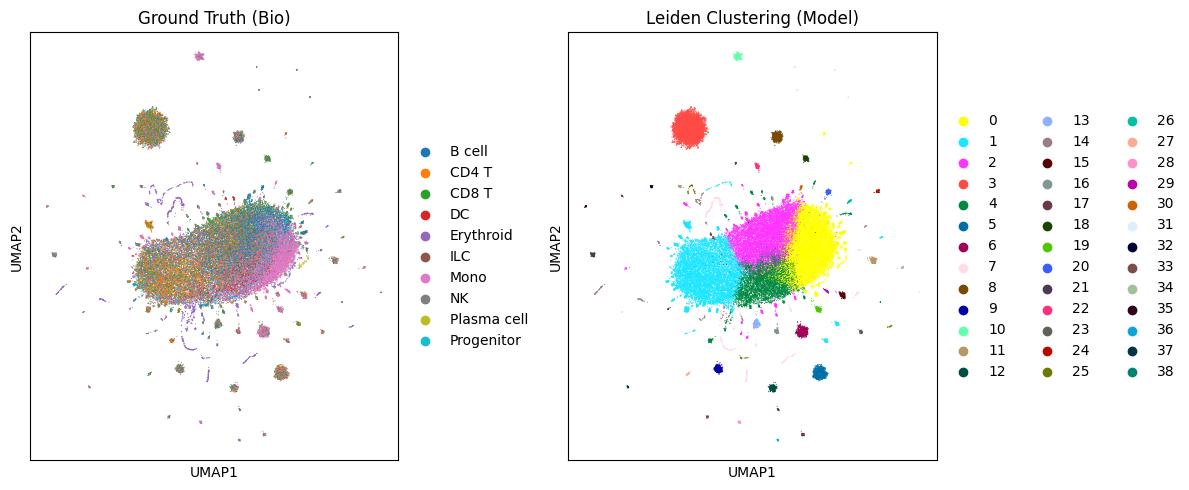


=== 混淆矩阵 (行: 真实类型, 列: 聚类簇) ===
leiden_debug     0     1     2     3     4    5    6    7    8    9  ...  29  \
celltype                                                             ...       
B cell        2870   506  2055   527   618   75    8    8  133    6  ...   0   
CD4 T          687  3351  1453  2037   710  310   35   14  163   26  ...   0   
CD8 T         1111  2295  2233  1975   602  174  108    2  135  151  ...   0   
DC             458   315   146   187   741   20    5    0   13    3  ...   1   
Erythroid      834  1825  1555   146   582   91    3  744   14    2  ...   0   
ILC             88    93   149    98    33   14    8    0    6   10  ...   0   
Mono          5390  1611  1090  1499  2093  207  544    5  133   95  ...  73   
NK             763  1347  1738   404   409   50   73    2   63  161  ...   0   
Plasma cell    203    56   110    10    73    2    0    0    3    0  ...   0   
Progenitor    1202   825   558   406   642   52   16   11   36    8  ...   0   

leiden_

In [5]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

# --- 关键步骤：强制重算一遍邻居图，确保万无一失 ---
# 这一步是为了防止你之前的 neighbors 实际上是基于 X_pca 算的
print("正在基于 latent_shared 重算邻居图...")
sc.pp.neighbors(adata, use_rep='latent_shared', n_neighbors=30) 

# --- 重新聚类 ---
# 先用一个稍微低一点的分辨率，防止切太碎
sc.tl.leiden(adata, resolution=0.3, key_added='leiden_debug')

# --- 绘图对比 ---
print("正在绘图对比...")
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# 左边画真实标签
sc.pl.umap(adata, color='celltype', ax=axs[0], title='Ground Truth (Bio)', show=False)
# 右边画聚类结果
sc.pl.umap(adata, color='leiden_debug', ax=axs[1], title='Leiden Clustering (Model)', show=False)

plt.tight_layout()
plt.show()

# --- 打印混淆矩阵 (真相探测器) ---
# 这张表会告诉你，你的 Cluster 0 到底包含了多少 T细胞，多少 B细胞
contingency_table = pd.crosstab(adata.obs['celltype'], adata.obs['leiden_debug'])
print("\n=== 混淆矩阵 (行: 真实类型, 列: 聚类簇) ===")
print(contingency_table)

In [2]:
!find /root -name "module.py"

/root/autodl-tmp/scMRDR/src/scMRDR/module.py
/root/miniconda3/envs/multiome/lib/python3.10/site-packages/debugpy/_vendored/pydevd/pydevd_attach_to_process/winappdbg/module.py
/root/miniconda3/envs/multiome/lib/python3.10/site-packages/jedi/inference/value/module.py
/root/miniconda3/lib/python3.12/site-packages/debugpy/_vendored/pydevd/pydevd_attach_to_process/winappdbg/module.py
/root/miniconda3/lib/python3.12/site-packages/jedi/inference/value/module.py
/root/miniconda3/lib/python3.12/site-packages/torch/nn/modules/module.py
/root/micromamba/envs/multiome310/lib/python3.10/site-packages/llvmlite/binding/module.py
/root/micromamba/envs/multiome310/lib/python3.10/site-packages/llvmlite/ir/module.py
/root/micromamba/envs/multiome310/lib/python3.10/site-packages/debugpy/_vendored/pydevd/pydevd_attach_to_process/winappdbg/module.py
/root/micromamba/envs/multiome310/lib/python3.10/site-packages/jedi/inference/value/module.py
/root/micromamba/pkgs/llvmlite-0.40.1-py310h1b8f574_0/lib/python3.